## O que será otimizado
| Hiperparâmetro | Faixa | Justificativa |
|---|---|---|
| Número de camadas encoder | 2–4 | Controla profundidade |
| Neurônios por camada | 64–512 | Controla largura |
| Dimensão latente | 8–64 | Gargalo de compressão |
| Dropout | 0.0–0.4 | Regularização |
| Learning rate | 1e-4 – 1e-2 | Convergência |
| Batch size | 16–128 | Trade-off bias/variância |

## Métrica de otimização
**val_loss mínima** — quanto menor, melhor o modelo reconstrói o ruído.
A val_loss é a métrica correta aqui porque o objetivo do autoencoder é
reconstruir ruído, não classificar.


In [6]:
import os, json, time, warnings
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import platform
SO = platform.system()

if SO == 'Windows':
    PASTA_PROJETO = r"C:\Users\vish8\OneDrive\Documentos\GitHub\TCC\Trabalho\artefacts"
else:
    PASTA_PROJETO = "/Users/alvarosamp/Documents/Projetos/TCC/Trabalho/artefacts"

PASTA_WINDOWS = os.path.join(PASTA_PROJETO, "data", "windows")
PASTA_MODELS  = os.path.join(PASTA_PROJETO, "models", "dense_ae")
PASTA_RESULTS = os.path.join(PASTA_PROJETO, "results")
PASTA_FIGS    = os.path.join(PASTA_PROJETO, "figures")

for p in [PASTA_MODELS, PASTA_RESULTS, PASTA_FIGS]:
    os.makedirs(p, exist_ok=True)

# Optuna settings
N_TRIALS   = 50    # número de combinações a testar
EPOCHS_OPT = 100    # épocas por trial (menor que o treino final)
PATIENCE   = 20   # EarlyStopping por trial

print(f"✅ SO: {SO}")
print(f"   N_TRIALS   : {N_TRIALS}")
print(f"   EPOCHS_OPT : {EPOCHS_OPT} por trial")
print()
print("Instalar Optuna se necessário...")


✅ SO: Windows
   N_TRIALS   : 50
   EPOCHS_OPT : 100 por trial

Instalar Optuna se necessário...


In [7]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "optuna", "-q"],
               capture_output=True)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
print(f"✅ Optuna {optuna.__version__}")

✅ Optuna 4.8.0


In [8]:
noise_data  = np.load(os.path.join(PASTA_WINDOWS, "windows_noise_v2.npz"))
events_data = np.load(os.path.join(PASTA_WINDOWS, "windows_events_v2.npz"))

X_train = noise_data['X_train'].astype(np.float32)
X_val   = noise_data['X_val'].astype(np.float32)
X_test_noise  = noise_data['X_test'].astype(np.float32)
X_test_events = events_data['X_test'].astype(np.float32)

N_AMOSTRAS = X_train.shape[1]

print(f"X_train       : {X_train.shape}")
print(f"X_val         : {X_val.shape}")
print(f"X_test_noise  : {X_test_noise.shape}")
print(f"X_test_events : {X_test_events.shape}")
print(f"N_AMOSTRAS    : {N_AMOSTRAS}")


X_train       : (342, 400)
X_val         : (73, 400)
X_test_noise  : (74, 400)
X_test_events : (1272, 400)
N_AMOSTRAS    : 400


In [9]:
#Construção do modelo -> Arquitetura flexivel

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.get_logger().setLevel('ERROR')

def construir_modelo(trial, n_amostras):
    """
    Constrói um Dense Autoencoder com hiperparâmetros sugeridos pelo Optuna.
    
    Parâmetros otimizados:
    - n_layers    : número de camadas no encoder (e simétricas no decoder)
    - units_i     : neurônios na i-ésima camada do encoder
    - latent_dim  : dimensão do bottleneck
    - dropout     : taxa de dropout
    - lr          : learning rate do Adam
    - batch_size  : tamanho do batch (retornado separado)
    """
    
    #Hiperparametros
    n_layers = trial.suggest_int("n_layers", 2,4)
    latent_dim = trial.suggest_int("latent_dim", 8, 64, step=8)
    dropout = trial.suggest_float("dropout", 0.0, 0.5, step=0.05)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    
    #Neuronios por camada - garantidndo que decrescem em direção ao bottleneck
    units = []
    max_units = trial.suggest_int("units_1", 128, 512, step=64)
    units.append(max_units)
    for i in range(1, n_layers):
        # Cada camada seguinte tem pelo menos metade da anterior
        prev = units[-1]
        u = trial.suggest_int(f'units_{i}',
                               max(64, prev // 4),
                               max(64, prev // 2),
                               step=32)
        units.append(u)
        
    # ── Encoder ──────────────────────────────────────────────────
    entrada = keras.Input(shape=(n_amostras,), name='entrada')
    x = entrada
    for i, u in enumerate(units):
        x = layers.Dense(u, activation='relu', name=f'enc_{i}')(x)
        if dropout > 0:
            x = layers.Dropout(dropout, name=f'drop_enc_{i}')(x)
    
    bottleneck = layers.Dense(latent_dim, activation='relu',
                               name='bottleneck')(x)
    
    # ── Decoder (simétrico) ───────────────────────────────────────
    x = bottleneck
    for i, u in enumerate(reversed(units)):
        x = layers.Dense(u, activation='relu', name=f'dec_{i}')(x)
        if dropout > 0:
            x = layers.Dropout(dropout, name=f'drop_dec_{i}')(x)
    
    saida = layers.Dense(n_amostras, activation='linear', name='saida')(x)
    
    modelo = keras.Model(entrada, saida, name='dense_ae_opt')
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mse'
    )
    return modelo


print("✅ Função construir_modelo() definida")
print("   Parâmetros otimizados: n_layers, units_i, latent_dim, dropout, lr")


✅ Função construir_modelo() definida
   Parâmetros otimizados: n_layers, units_i, latent_dim, dropout, lr


In [10]:
def objective(trial):
    """
    Função objetivo para o Optuna.
    Retorna a melhor val_loss obtida neste trial.
    """
    # Limpar sessão do Keras para evitar acúmulo de memória
    keras.backend.clear_session()
    
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    
    try:
        modelo = construir_modelo(trial, N_AMOSTRAS)
        
        early_stop = keras.callbacks.EarlyStopping(
            monitor             = 'val_loss',
            patience            = PATIENCE,
            restore_best_weights= True,
            verbose             = 0
        )
        
        # Pruning: Optuna pode interromper trials ruins cedo
        pruning_cb = optuna.integration.TFKerasPruningCallback(
            trial, 'val_loss'
        )
        
        hist = modelo.fit(
            X_train, X_train,
            epochs          = EPOCHS_OPT,
            batch_size      = batch_size,
            validation_data = (X_val, X_val),
            callbacks       = [early_stop, pruning_cb],
            verbose         = 0
        )
        
        best_val_loss = min(hist.history['val_loss'])
        return best_val_loss
    
    except Exception as e:
        # Trial falhou — retorna valor alto para o Optuna descartar
        return 1.0


print("✅ Função objective() definida")
print(f"   Cada trial treina por até {EPOCHS_OPT} épocas com EarlyStopping(patience={PATIENCE})")


✅ Função objective() definida
   Cada trial treina por até 100 épocas com EarlyStopping(patience=20)


In [11]:
print(f"Iniciando otimização com {N_TRIALS} trials...")
print("(Isso pode levar alguns minutos)")
print("-" * 60)

# Criar estudo com pruner (elimina trials ruins cedo)
pruner = optuna.pruners.MedianPruner(
    n_startup_trials = 5,
    n_warmup_steps   = 10
)

study = optuna.create_study(
    direction = 'minimize',      # minimizar val_loss
    pruner    = pruner,
    sampler   = optuna.samplers.TPESampler(seed=42)
)

t_opt_ini = time.time()
study.optimize(
    objective,
    n_trials  = N_TRIALS,
    timeout   = 600,             # máximo 10 minutos no total
    show_progress_bar = True
)
t_opt = time.time() - t_opt_ini

print(f"\n✅ Otimização concluída em {t_opt:.0f}s")
print(f"   Trials completados : {len(study.trials)}")
print(f"   Melhor val_loss    : {study.best_value:.6f}")
print()
print("Melhores hiperparâmetros encontrados:")
for k, v in study.best_params.items():
    print(f"  {k:20s} : {v}")


Iniciando otimização com 50 trials...
(Isso pode levar alguns minutos)
------------------------------------------------------------


Best trial: 0. Best value: 1: 100%|██████████| 50/50 [00:06<00:00,  7.40it/s, 6.75/600 seconds]


✅ Otimização concluída em 7s
   Trials completados : 50
   Melhor val_loss    : 1.000000

Melhores hiperparâmetros encontrados:
  batch_size           : 32
  n_layers             : 2
  latent_dim           : 16
  dropout              : 0.0
  lr                   : 0.005399484409787433
  units_1              : 384


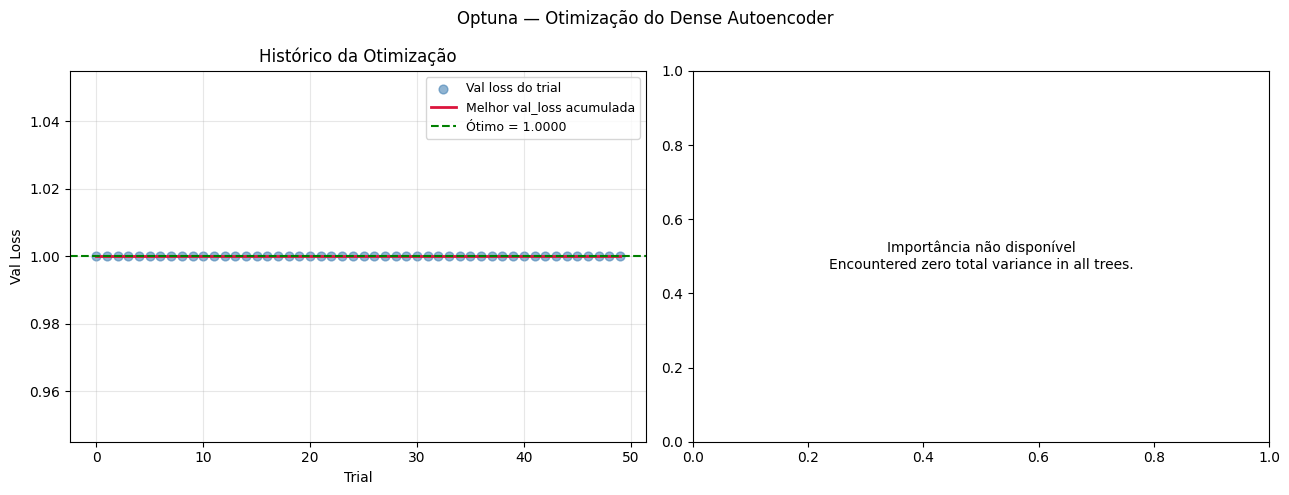


Top 5 melhores trials:
   Trial     Val Loss  Params resumidos
----------------------------------------------------------------------
       0     1.000000  layers=2 latent=16 units0=? drop=0.00 lr=5.4e-03
       1     1.000000  layers=2 latent=16 units0=? drop=0.10 lr=4.1e-04
       2     1.000000  layers=2 latent=24 units0=? drop=0.25 lr=3.7e-03
       3     1.000000  layers=2 latent=8 units0=? drop=0.50 lr=8.5e-03
       4     1.000000  layers=2 latent=32 units0=? drop=0.00 lr=6.6e-03


In [12]:
# ── Histórico de trials ──────────────────────────────────────────
vals    = [t.value for t in study.trials if t.value is not None]
trial_n = [t.number for t in study.trials if t.value is not None]
best_so_far = [min(vals[:i+1]) for i in range(len(vals))]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(trial_n, vals, alpha=0.6, color='steelblue', s=40, label='Val loss do trial')
ax.plot(trial_n, best_so_far, 'crimson', lw=2, label='Melhor val_loss acumulada')
ax.axhline(study.best_value, color='green', ls='--', lw=1.5,
           label=f'Ótimo = {study.best_value:.4f}')
ax.set_xlabel('Trial')
ax.set_ylabel('Val Loss')
ax.set_title('Histórico da Otimização')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Importância dos hiperparâmetros ──────────────────────────────
try:
    importances = optuna.importance.get_param_importances(study)
    params_imp  = list(importances.keys())[:8]
    vals_imp    = [importances[k] for k in params_imp]
    
    ax = axes[1]
    bars = ax.barh(params_imp, vals_imp, color='steelblue', alpha=0.8)
    ax.set_xlabel('Importância relativa')
    ax.set_title('Importância dos Hiperparâmetros')
    ax.grid(True, alpha=0.3, axis='x')
    
    for bar, val in zip(bars, vals_imp):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
except Exception as e:
    axes[1].text(0.5, 0.5, f'Importância não disponível\n{e}',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.suptitle('Optuna — Otimização do Dense Autoencoder', fontsize=12)
plt.tight_layout()
fig_path = os.path.join(PASTA_FIGS, "passo4b_optuna_historico.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

# ── Top 5 trials ──────────────────────────────────────────────────
print("\nTop 5 melhores trials:")
print(f"  {'Trial':>6} {'Val Loss':>12}  Params resumidos")
print("-" * 70)
trials_sorted = sorted([t for t in study.trials if t.value],
                        key=lambda t: t.value)
for t in trials_sorted[:5]:
    params_str = f"layers={t.params.get('n_layers','?')} " \
                 f"latent={t.params.get('latent_dim','?')} " \
                 f"units0={t.params.get('units_0','?')} " \
                 f"drop={t.params.get('dropout','?'):.2f} " \
                 f"lr={t.params.get('lr',0):.1e}"
    print(f"  {t.number:>6} {t.value:>12.6f}  {params_str}")


In [13]:
print("Treinando modelo final com os melhores hiperparâmetros...")
print(f"  Params: {study.best_params}")
print()

keras.backend.clear_session()

# Criar trial sintético com os melhores parâmetros
best_trial = study.best_trial
batch_best  = study.best_params.get('batch_size', 32)

modelo_opt = construir_modelo(best_trial, N_AMOSTRAS)
modelo_opt.summary()

model_path = os.path.join(PASTA_MODELS, "dense_ae_opt.keras")

early_stop = keras.callbacks.EarlyStopping(
    monitor             = 'val_loss',
    patience            = 20,
    restore_best_weights= True,
    verbose             = 1
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,
    patience = 10,
    min_lr   = 1e-6,
    verbose  = 0
)
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath       = model_path,
    monitor        = 'val_loss',
    save_best_only = True,
    verbose        = 0
)

t_treino_ini = time.time()
hist_opt = modelo_opt.fit(
    X_train, X_train,
    epochs          = 300,
    batch_size      = batch_best,
    validation_data = (X_val, X_val),
    callbacks       = [early_stop, reduce_lr, checkpoint],
    verbose         = 1
)
t_treino = time.time() - t_treino_ini

print(f"\n✅ Treino final concluído em {t_treino:.1f}s")
print(f"   Épocas           : {len(hist_opt.history['loss'])}")
print(f"   Melhor val_loss  : {min(hist_opt.history['val_loss']):.6f}")


Treinando modelo final com os melhores hiperparâmetros...
  Params: {'batch_size': 32, 'n_layers': 2, 'latent_dim': 16, 'dropout': 0.0, 'lr': 0.005399484409787433, 'units_1': 384}



Model: "dense_ae_opt"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_0 (Dense)                   │ (None, 384)            │       153,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 384)            │       147,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │         6,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_0 (Dense)                   │ (None, 384)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 384)            │       147,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ (None, 400)            │       154,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 616,352 (2.35 MB)

 Trainable params: 616,352 (2.35 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.0013 - val_loss: 0.9998 - learning_rate: 0.0054
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9984 - val_loss: 1.0017 - learning_rate: 0.0054
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9978 - val_loss: 1.0012 - learning_rate: 0.0054
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9975 - val_loss: 1.0016 - learning_rate: 0.0054
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9975 - val_loss: 1.0017 - learning_rate: 0.0054
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9974 - val_loss: 1.0014 - learning_rate: 0.0054
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9974 - val_loss: 1.0019 - learning_rate: 0.0054
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9974 - val_loss: 1.0017 - learning_rate: 0.0054
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9974 - val_loss: 1.0017 - learning_rate: 0.0054
Epoch 10/300
11/11

Avaliando modelos...


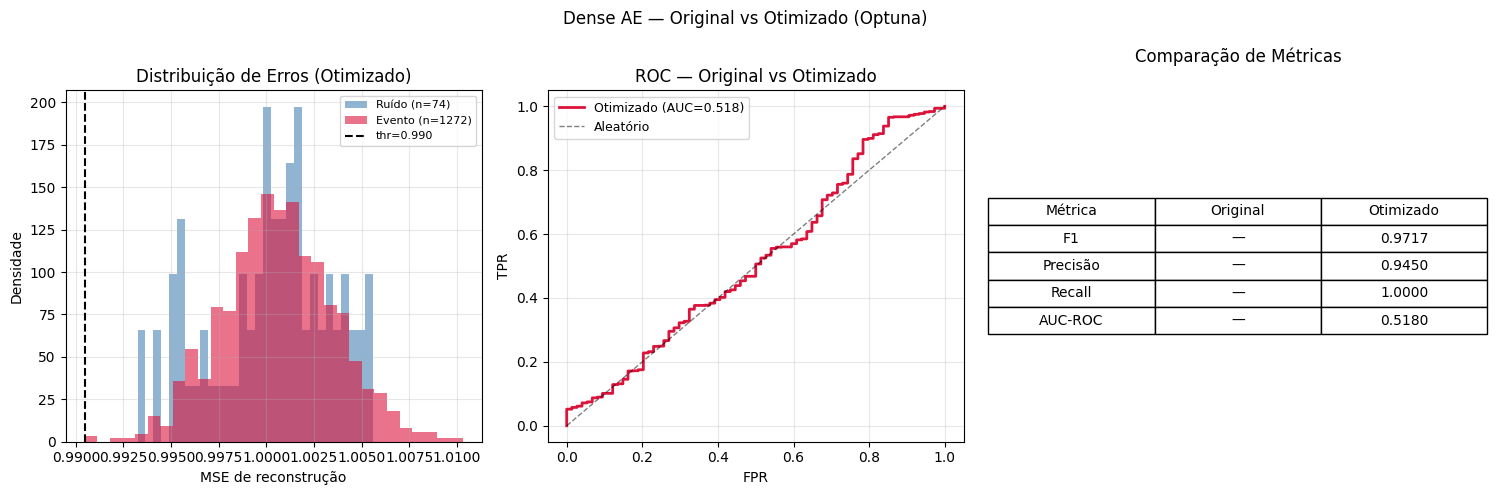

DENSE AE OTIMIZADO — RESULTADO FINAL
  Parâmetros      : 616,352
  Tamanho         : 7265.3 KB
  F1              : 0.9717
  Precisão        : 0.9450
  Recall          : 1.0000
  AUC-ROC         : 0.5180
  Threshold ótimo : 0.990456

Melhores hiperparâmetros:
  batch_size           : 32
  n_layers             : 2
  latent_dim           : 16
  dropout              : 0.0
  lr                   : 0.005399484409787433
  units_1              : 384

💾 Salvo: C:\Users\vish8\OneDrive\Documentos\GitHub\TCC\Trabalho\artefacts\results\resultado_dense_ae_opt.json

🚀 Passo 4b concluído → Próximo: Passo 5 — CNN 1D Autoencoder


In [14]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

# Carregar modelo otimizado
modelo_final = keras.models.load_model(model_path)

def avaliar_modelo(modelo, X_test_noise, X_test_events):
    """Calcula métricas completas para um modelo."""
    erros_n = np.mean((X_test_noise - modelo.predict(X_test_noise, verbose=0))**2, axis=1)
    erros_e = np.mean((X_test_events - modelo.predict(X_test_events, verbose=0))**2, axis=1)
    
    y_scores = np.concatenate([erros_n, erros_e])
    y_true   = np.concatenate([np.zeros(len(erros_n)), np.ones(len(erros_e))])
    
    from sklearn.metrics import roc_curve
    fpr, tpr, thrs = roc_curve(y_true, y_scores)
    f1_vals = [f1_score(y_true, (y_scores>=t).astype(int), zero_division=0) for t in thrs]
    idx     = np.argmax(f1_vals)
    thr_opt = thrs[idx]
    
    y_pred = (y_scores >= thr_opt).astype(int)
    
    try: auc = roc_auc_score(y_true, y_scores)
    except: auc = 0.0
    
    return {
        'f1'       : f1_score(y_true, y_pred, zero_division=0),
        'precisao' : precision_score(y_true, y_pred, zero_division=0),
        'recall'   : recall_score(y_true, y_pred, zero_division=0),
        'auc'      : auc,
        'threshold': float(thr_opt),
        'erros_n'  : erros_n,
        'erros_e'  : erros_e,
        'fpr'      : fpr,
        'tpr'      : tpr,
        'auc_roc'  : auc,
    }

print("Avaliando modelos...")
metricas_opt = avaliar_modelo(modelo_final, X_test_noise, X_test_events)

# Tentar carregar modelo original para comparar
model_orig_path = os.path.join(PASTA_MODELS, "dense_ae.h5")
if os.path.exists(model_orig_path):
    try:
        modelo_orig   = keras.models.load_model(model_orig_path)
        metricas_orig = avaliar_modelo(modelo_orig, X_test_noise, X_test_events)
        tem_original  = True
    except:
        tem_original = False
else:
    tem_original = False

# ── Gráfico comparativo ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Distribuição de erros — otimizado
ax = axes[0]
ax.hist(metricas_opt['erros_n'], bins=30, density=True, alpha=0.6,
        color='steelblue', label=f'Ruído (n={len(X_test_noise)})')
ax.hist(metricas_opt['erros_e'], bins=30, density=True, alpha=0.6,
        color='crimson', label=f'Evento (n={len(X_test_events)})')
ax.axvline(metricas_opt['threshold'], color='black', ls='--', lw=1.5,
           label=f"thr={metricas_opt['threshold']:.3f}")
ax.set_xlabel('MSE de reconstrução')
ax.set_ylabel('Densidade')
ax.set_title('Distribuição de Erros (Otimizado)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Curva ROC comparativa
ax = axes[1]
ax.plot(metricas_opt['fpr'], metricas_opt['tpr'], 'crimson', lw=2,
        label=f"Otimizado (AUC={metricas_opt['auc']:.3f})")
if tem_original:
    ax.plot(metricas_orig['fpr'], metricas_orig['tpr'], 'steelblue', lw=2,
            label=f"Original (AUC={metricas_orig['auc']:.3f})")
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Aleatório')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — Original vs Otimizado')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Tabela de métricas
ax = axes[2]
ax.axis('off')
metricas_tabela = [['Métrica', 'Original', 'Otimizado']]
if tem_original:
    metricas_tabela += [
        ['F1',       f"{metricas_orig['f1']:.4f}",      f"{metricas_opt['f1']:.4f}"],
        ['Precisão', f"{metricas_orig['precisao']:.4f}", f"{metricas_opt['precisao']:.4f}"],
        ['Recall',   f"{metricas_orig['recall']:.4f}",  f"{metricas_opt['recall']:.4f}"],
        ['AUC-ROC',  f"{metricas_orig['auc']:.4f}",     f"{metricas_opt['auc']:.4f}"],
    ]
else:
    metricas_tabela += [
        ['F1',       '—', f"{metricas_opt['f1']:.4f}"],
        ['Precisão', '—', f"{metricas_opt['precisao']:.4f}"],
        ['Recall',   '—', f"{metricas_opt['recall']:.4f}"],
        ['AUC-ROC',  '—', f"{metricas_opt['auc']:.4f}"],
    ]

tabela = ax.table(cellText=metricas_tabela[1:],
                   colLabels=metricas_tabela[0],
                   loc='center', cellLoc='center')
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.8)
ax.set_title('Comparação de Métricas', pad=20)

plt.suptitle('Dense AE — Original vs Otimizado (Optuna)', fontsize=12)
plt.tight_layout()
fig_path = os.path.join(PASTA_FIGS, "passo4b_comparacao.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

# ── Resultado final ───────────────────────────────────────────────
n_params = modelo_final.count_params()
tamanho_kb = os.path.getsize(model_path) / 1024

print("=" * 65)
print("DENSE AE OTIMIZADO — RESULTADO FINAL")
print("=" * 65)
print(f"  Parâmetros      : {n_params:,}")
print(f"  Tamanho         : {tamanho_kb:.1f} KB")
print(f"  F1              : {metricas_opt['f1']:.4f}")
print(f"  Precisão        : {metricas_opt['precisao']:.4f}")
print(f"  Recall          : {metricas_opt['recall']:.4f}")
print(f"  AUC-ROC         : {metricas_opt['auc']:.4f}")
print(f"  Threshold ótimo : {metricas_opt['threshold']:.6f}")
print()
print("Melhores hiperparâmetros:")
for k, v in study.best_params.items():
    print(f"  {k:20s} : {v}")

resultado = {
    "metodo"           : "Dense Autoencoder (Optuna)",
    "versao"           : "2.0",
    "n_trials_optuna"  : len(study.trials),
    "best_val_loss"    : study.best_value,
    "hiperparametros"  : study.best_params,
    "n_params"         : int(n_params),
    "tamanho_kb"       : float(tamanho_kb),
    "f1"               : float(metricas_opt['f1']),
    "precisao"         : float(metricas_opt['precisao']),
    "recall"           : float(metricas_opt['recall']),
    "auc"              : float(metricas_opt['auc']),
    "threshold"        : float(metricas_opt['threshold']),
    "tflite_kb"        : None,
    "tflite_quant_kb"  : None,
    "tflite_ms"        : None,
    "tflite_quant_ms"  : None,
}

result_path = os.path.join(PASTA_RESULTS, "resultado_dense_ae_opt.json")
with open(result_path, 'w') as f:
    json.dump(resultado, f, indent=2)

print(f"\n💾 Salvo: {result_path}")
print("\n🚀 Passo 4b concluído → Próximo: Passo 5 — CNN 1D Autoencoder")
